# 05. Operational Strategy

## Question
**탐지 결과를 실제 FDS 운영 기준으로 어떻게 활용할 수 있는가?**

## Objective
Risk Score를 기반으로 거래 위험도를 구분하고,
위험 수준에 따른 대응 전략을 설계한다.

In [85]:
best_threshold = cost_ee_df.loc[cost_ee_df["cost"].idxmin()]["threshold"]
medium_threshold = best_threshold * 0.90  # High 기준점의 90% 지점

#High Risk는 Business Cost 최소화 기준으로 도출된 최적 Threshold를 사용
#Medium Risk는 즉시 차단 대상은 아니지만 추가 인증이 필요한 잠재 위험군을 정의하기 위해 High Threshold의 85% 수준으로 운영 정책을 설정하였다.

def get_risk_level(score):
    if score >= best_threshold:
        return "High"
    elif score >= medium_threshold: # Medium은 High 직전의 잠재 위험군
        return "Medium"
    else:
        return "Low"

score_ee_df["risk_level"] = score_ee_df["scaled_score"].apply(get_risk_level)

In [86]:
fraud_in_high = score_ee_df[(score_ee_df["risk_level"] == "High") & (score_ee_df["y_true"] == 1)].shape[0]
total_fraud = score_ee_df["y_true"].sum()
coverage = (fraud_in_high / total_fraud) * 100

print(f"High Risk 구간의 사기 탐지율(Recall) : {coverage:.2f}%")

High Risk 구간의 사기 탐지율(Recall) : 83.33%


In [87]:
score_ee_df

,y_true,scores,scaled_score,risk_level
0,0,-432692.996181,0.000499,Low
1,0,-432671.973327,0.001095,Low
2,0,-432695.657515,0.000423,Low
3,0,-432680.009482,0.000867,Low
4,0,-431970.324030,0.021007,Low
...,...,...,...,...
28457,0,-432691.053743,0.000554,Low
28458,0,-432694.248933,0.000463,Low
28459,0,-432620.354926,0.002560,Low
28460,0,-432705.345972,0.000148,Low


In [88]:
risk_dist = (score_ee_df
             .groupby(["risk_level", "y_true"])
             .size()
             .reset_index(name = "count")
            )
print(risk_dist)

  risk_level  y_true  count
0       High       0      4
1       High       1     25
2        Low       0  28427
3        Low       1      5
4     Medium       0      1


In [89]:
# 각 Risk Level별 건수 및 실제 사기(y_true=1) 포함 건수 확인
risk_summary = score_ee_df.groupby("risk_level").agg(
    total_count=("y_true", "count"),
    fraud_count=("y_true", "sum")
)

risk_summary["traffic_ratio(%)"] = (risk_summary["total_count"] / len(score_ee_df)) * 100
risk_summary["fraud_ratio(%)"] = (risk_summary["fraud_count"] / score_ee_df["y_true"].sum()) * 100

print(risk_summary)

            total_count  fraud_count  traffic_ratio(%)  fraud_ratio(%)
risk_level                                                            
High                 29           25          0.101890       83.333333
Low               28432            5         99.894596       16.666667
Medium                1            0          0.003513        0.000000


In [90]:
print("=== [Risk Level별 트래픽 및 사기 건수 분포] ===")
print(
    score_ee_df.groupby("risk_level").agg(
        총건수=("y_true", "count"), 실제사기건수=("y_true", "sum")
    )
)

fraud_in_high = score_ee_df[
    (score_ee_df["risk_level"] == "High") & (score_ee_df["y_true"] == 1)
].shape[0]
total_fraud = score_ee_df["y_true"].sum()
coverage = (fraud_in_high / total_fraud) * 100

print(
    f"\nHigh Risk 기준점: {best_threshold:.2f}점 | Medium 기준점: {medium_threshold:.2f}점"
)
print(f"High Risk 구간의 사기 탐지율(Recall) : {coverage:.2f}%")

=== [Risk Level별 트래픽 및 사기 건수 분포] ===
              총건수  실제사기건수
risk_level               
High           29      25
Low         28432       5
Medium          1       0

High Risk 기준점: 100.00점 | Medium 기준점: 90.00점
High Risk 구간의 사기 탐지율(Recall) : 83.33%


In [91]:
normal_dist = (
    score_ee_df[score_ee_df['y_true'] == 0]['risk_level']
    .value_counts(normalize=True)
    .mul(100)
)

fraud_dist = (
    score_ee_df[score_ee_df['y_true'] == 1]['risk_level']
    .value_counts(normalize=True)
    .mul(100)
)

plot_df = pd.DataFrame({
    'Normal': normal_dist,
    'Fraud': fraud_dist
}).fillna(0)

plot_df = plot_df.reindex(['High','Medium', 'Low'])
plot_df

,Normal,Fraud
risk_level,,
High,0.014069,83.333333
Medium,0.003517,0.000000
Low,99.982414,16.666667


In [92]:
pd.crosstab(
    score_ee_df["y_true"],
    score_ee_df["risk_level"],
    normalize="index"
) * 100

risk_level,High,Low,Medium
y_true,,,
0,0.014069,99.982414,0.003517
1,83.333333,16.666667,0.000000


In [93]:
sns.set_theme(style = "white")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["font.family"] = "Malgun Gothic"

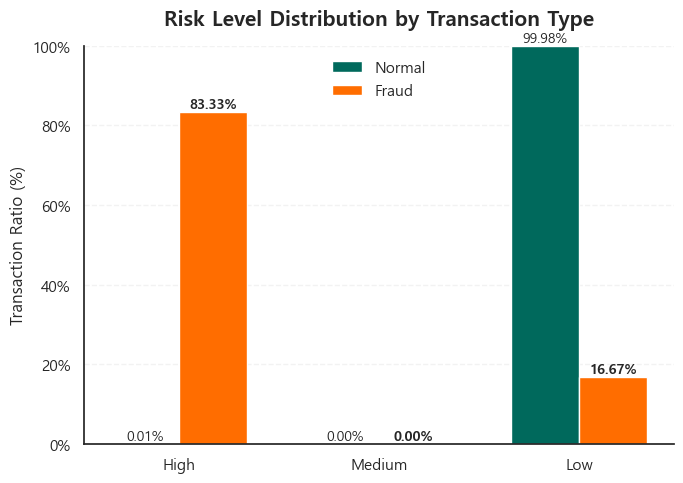

In [94]:
# 데이터
risk_levels = ["High", "Medium", "Low"]

normal = plot_df.loc[risk_levels, "Normal"].values
fraud = plot_df.loc[risk_levels, "Fraud"].values

x = np.arange(len(risk_levels))
width = 0.34

fig, ax = plt.subplots(figsize=(7,5))

# 색상
NORMAL_COLOR = "#00695C"
FRAUD_COLOR = "#FF6D00"

bars1 = ax.bar(x - width/2, normal, width, color = NORMAL_COLOR, label = "Normal")

bars2 = ax.bar(x + width/2, fraud, width, color=FRAUD_COLOR, label="Fraud")

# 값 표시
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.2f}%", ha="center", fontsize=10)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.2f}%", ha="center", fontsize=10, fontweight="bold")

# 스타일
ax.set_xticks(x)
ax.set_xticklabels(risk_levels)

ax.set_ylim(0,100)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_ylabel("Transaction Ratio (%)")

ax.set_title("Risk Level Distribution by Transaction Type", fontsize=15, fontweight="bold", pad=15)

ax.grid(axis="y", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()